## RNN

## 🔄 Redes Neuronales Recurrentes para Análisis de Sentimiento

### ¿Por qué RNN y no MLP para texto?

Un MLP con TF-IDF **pierde el orden** de las palabras. La frase "no es buena" y "es buena, no es mala" tienen palabras parecidas pero significados opuestos. Las RNN procesan texto **token a token**, manteniendo un estado oculto que captura el contexto anterior:

```
"La  →  película  →  no  →  es  →  buena"
 h₁       h₂         h₃    h₄     h₅  → predicción
```

Cada estado `hₜ` depende de la palabra actual y del estado anterior `hₜ₋₁`, creando una **memoria implícita** de la secuencia.

---
### 🗂️ Dataset: IMDB Movie Reviews
- **25,000 reseñas** de entrenamiento + 25,000 de test
- Etiquetas binarias: **0 = negativa**, **1 = positiva**
- Reseñas ya tokenizadas: cada palabra es un índice numérico según su frecuencia en el corpus

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, LSTM, Dense, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.datasets import imdb


#### 0. Load data

x_train y x_test: Son listas de reseñas, pero no en forma de texto; cada reseña se codifica como una secuencia de enteros. Cada entero representa la posición de una palabra en el diccionario generado por el dataset en función de su frecuencia. Es decir, por ejemplo, si configuras num_words=max_features (digamos, 10,000), sólo se conservarán las 10,000 palabras más frecuentes, y las demás se descartarán o se marcarán como desconocidas. Esto ayuda a reducir el ruido y manejar un vocabulario de tamaño fijo.  

y_train y y_test: Son las etiquetas asociadas a cada reseña. Generalmente, en el dataset IMDb, estas etiquetas son binarias:

0 para reseñas negativas  

1 para reseñas positivas  

In [2]:
max_features = 10000
maxlen = 500

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

# Let's take a look at what the review is like!
print("First review:")
print(x_train)

print("\nFirst review label:")
print(y_train)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
First review:
[list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19

### ⚙️ Parámetros de carga del dataset

- **`max_features = 10000`**: solo usamos las **10,000 palabras más frecuentes** del vocabulario. Las menos frecuentes son ruido (nombres propios, erratas) y añadirlas no mejoraría el modelo.
- **`maxlen = 500`**: longitud máxima de cada secuencia. Reseñas más largas se truncan, más cortas se rellenan con ceros (padding).

> 💡 El balance entre `max_features` y `maxlen` afecta directamente al coste computacional y al riesgo de overfitting.

### 🔡 De números a palabras: el diccionario inverso

El dataset IMDB almacena cada reseña como una lista de enteros. Para *leer* una reseña, necesitamos el mapeo inverso: entero → palabra.

**Índices reservados:**
- `0` → padding (relleno)
- `1` → `<START>` (inicio de secuencia)
- `2` → `<UNK>` (palabra desconocida)

Por eso restamos 3 al índice: el índice real en el diccionario es `idx - 3`.

In [3]:

# Obtén el diccionario que mapea cada palabra a un índice
word_index = imdb.get_word_index()

# Construye el diccionario inverso: índice -> palabra
reverse_word_index = {value: key for key, value in word_index.items()}

# Función para decodificar una reseña
def decode_review(review):
    # Resta 3 a cada índice para compensar los tokens reservados: 
    # 0: padding, 1: inicio de secuencia, 2: word_unknown
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in review])

# Decodifica y muestra la primera reseña de entrenamiento
print(x_train[1])
print(decode_review(x_train[1]))

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
[1, 194, 1153, 194, 8255, 78, 228, 5, 6, 1463, 4369, 5012, 134, 26, 4, 715, 8, 118, 1634, 14, 394, 20, 13, 119, 954, 189, 102, 5, 207, 110, 3103, 21, 14, 69, 188, 8, 30, 23, 7, 4, 249, 126, 93, 4, 114, 9, 2300, 1523, 5, 647, 4, 116, 9, 35, 8163, 4, 229, 9, 340, 1322, 4, 118, 9, 4, 130, 4901, 19, 4, 1002, 5, 89, 29, 952, 46, 37, 4, 455, 9, 45, 43, 38, 1543, 1905, 398, 4, 1649, 26, 6853, 5, 163, 11, 3215, 2, 4, 1153, 9, 194, 775, 7, 8255, 2, 349, 2637, 148, 605, 2, 8003, 15, 123, 125, 68, 2, 6853, 15, 349, 165, 4362, 98, 5, 4, 228, 9, 43, 2, 1157, 15, 299, 120, 5, 120, 174, 11, 220, 175, 136, 50, 9, 4373, 228, 8255, 5, 2, 656, 245, 2350, 5, 4, 9837, 131, 152, 491, 18, 2, 32, 7464, 1212, 14, 9, 6, 371, 78, 22, 625, 64, 1382, 9, 8, 168, 145, 23, 4, 1690, 15, 16, 4, 1355, 5, 28, 6, 52, 154, 462, 33, 89, 78, 285, 16, 145, 95]
? big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love c

#### ¿Que proceso de codificacion se ha seguido? (leer)



El proceso se basa en una tokenización muy sencilla y en un análisis de frecuencia de palabras. En el caso del dataset IMDB, las reseñas ya han sido preprocesadas de la siguiente manera:  

**Tokenización**: Cada reseña se divide en palabras (o tokens) mediante un método simple de separación, generalmente eliminando puntuación y pasando todo a minúsculas.  

**Construcción del diccionario**: Se analiza el corpus completo para contar la frecuencia de aparición de cada palabra. Las palabras se ordenan por frecuencia y se les asigna un entero. Las palabras más frecuentes se asignan a números más bajos.  

**Conversión de reseñas**: Por cada reseña, cada palabra es reemplazada por su entero correspondiente, de acuerdo al diccionario construido. De esta forma, la reseña se transforma en una secuencia de números. Además, se reservan algunos índices (por ejemplo, 0, 1 y 2) para tokens especiales como padding, inicio de secuencia y palabras desconocidas.  

El parámetro num_words=max_features se utiliza para limitar el diccionario a las palabras más frecuentes (por ejemplo, las 10,000 más frecuentes). Esto ayuda a reducir el tamaño del vocabulario y a ignorar palabras poco comunes o ruido en los datos.  

En resumen, no se emplea un algoritmo complejo avanzado, sino un proceso de tokenización junto con un análisis simple de frecuencias. Esto convierte cada reseña en una secuencia numérica que representa la posición de cada palabra dentro de un ranking por frecuencia.  

### 🔡 De números a palabras: el diccionario inverso

El dataset IMDB almacena cada reseña como una lista de enteros. Para *leer* una reseña, necesitamos el mapeo inverso: entero → palabra.

**Índices reservados:**
- `0` → padding (relleno)
- `1` → `<START>` (inicio de secuencia)
- `2` → `<UNK>` (palabra desconocida)

Por eso restamos 3 al índice: el índice real en el diccionario es `idx - 3`.

In [4]:

# To transform the integers back into words
word_index = imdb.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_review = ' '.join([reverse_word_index.get(i - 3, '?') for i in x_train[0]])
print("\nDecoded review:")
print(decoded_review)
#print(decode_review(x_train[1]))


Decoded review:
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have d

#### 2. Procesamiento

Utilizamos pad_sequences para que todas las secuencias tengan la misma longitud.  
Si no llega a max_len rellena si se pasa entonces trunca.
Por deecto rellena por el principio y con ceros.

### 📏 Padding: igualar la longitud de todas las secuencias

Las redes neuronales procesan **batches**: grupos de ejemplos al mismo tiempo. Para poder apilarlos en un tensor, todas las secuencias deben tener la misma longitud.

`pad_sequences` hace dos cosas:
1. **Rellena** (padding) las reseñas cortas con ceros al principio (por defecto `padding='pre'`)
2. **Trunca** las reseñas largas, eliminando tokens del principio

```
Reseña de 320 tokens → [0, 0, ..., 0, t₁, t₂, ..., t₃₂₀]  (longitud 500)
Reseña de 620 tokens → [t₁₂₁, t₁₂₂, ..., t₆₂₀]             (longitud 500)
```

In [5]:
# ensure that all sequences in a list have the same length
# it's done by padding (i.e., adding) zeros at the beginning of each sequence
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

---
## 🏗️ Construcción de los modelos recurrentes

### Arquitectura GRU vs LSTM

Ambos son variantes de RNN que solucionan el problema del **gradiente desvanecido** de las RNN simples. La diferencia principal:

| | GRU | LSTM |
|---|---|---|
| Puertas | 2 (update, reset) | 3 (input, forget, output) |
| Estados | 1 (hidden) | 2 (hidden + cell) |
| Parámetros | ~75% de LSTM | 100% |
| Velocidad | Más rápida | Más lenta |
| Memoria largo plazo | Buena | Excelente |

> **Regla práctica**: prueba GRU primero. Si necesitas capturar dependencias muy largas (> 200 pasos), LSTM puede ser mejor.

#### 3. Build GNU model



In [6]:
def create_gru_model(input_length, vocab_size, embedding_dim=100, gru_units=128):
    # Create a sequential model (stacking layers on top of each other).
    model = Sequential()
    # Create an embedding layer to represent words as vectors.
    model.add(Embedding(vocab_size, embedding_dim))
    # Add a GRU layer (type of recurrent layer) to process sequences of words.
    model.add(GRU(gru_units))
    # Add a dense layer (fully connected) with sigmoid activation for binary classification (0 or 1).
    model.add(Dense(1, activation='sigmoid'))
    # Compile the model with loss function, optimizer, and metrics.
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Create a GRU model with specific input length and vocabulary size.
gru_model = create_gru_model(input_length=maxlen, vocab_size=max_features)
# Print a summary of the model architecture.
gru_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 🔍 Anatomía del modelo GRU

```
Entrada: secuencia de 500 tokens (IDs numéricos)
    ↓
Embedding(10000, 100): cada token → vector de 100 dimensiones
    ↓  forma: (batch, 500, 100)
GRU(128): procesa la secuencia, devuelve el último estado oculto
    ↓  forma: (batch, 128)
Dense(1, sigmoid): probabilidad de sentimiento positivo
    ↓  forma: (batch, 1)
```

**¿Por qué Embedding en lugar de one-hot?**
Un one-hot de 10,000 palabras es un vector muy disperso (9,999 ceros). El Embedding aprende una representación densa de 100 dimensiones donde palabras similares están cerca en el espacio vectorial.

#### 4. Building the LSTM model

In [7]:
def create_lstm_model(input_length, vocab_size, embedding_dim=100, lstm_units=128):
    # Create a sequential model (stacking layers)
    model = Sequential()
    # Create an embedding layer to represent words as vectors
    model.add(Embedding(vocab_size, embedding_dim, input_length=input_length))
    # Add an LSTM layer to process sequences of words
    model.add(LSTM(lstm_units))
    # Add a dense layer with sigmoid activation for binary classification (0 or 1)
    model.add(Dense(1, activation='sigmoid'))
    # Compile the model with loss function, optimizer, and metrics
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Create an LSTM model with specific input length and vocabulary size
lstm_model = create_lstm_model(input_length=maxlen, vocab_size=max_features)
# Print a summary of the model architecture
lstm_model.summary()

c:\Users\tomas\envs\dl\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### 🔍 Anatomía del modelo LSTM

La diferencia respecto al GRU es la capa recurrente: LSTM mantiene dos estados en cada paso de tiempo:
- **Hidden state `hₜ`**: memoria a corto plazo, pasa al paso siguiente y es la salida visible
- **Cell state `cₜ`**: memoria a largo plazo, fluye por la red con mínimas modificaciones

Las tres puertas controlan qué información entra, qué se olvida y qué se expone al exterior.

#### 5. Training and evaluating the models

In [8]:
print(x_train.dtype) 
print(y_train.dtype) 
print(x_test.dtype) 
print(y_test.dtype) 

int32
int64
int32
int64


---
## 🏋️ Entrenamiento y comparación de modelos

### Parámetros de entrenamiento

- **`epochs=1`**: solo 1 época por limitaciones de tiempo en clase. En producción, 5-10 épocas mejoran significativamente los resultados.
- **`batch_size=32`**: el modelo ve 32 reseñas antes de actualizar los pesos
- **`validation_split=0.2`**: el 20% del training set se usa para monitorizar si hay overfitting

> ⚠️ Con solo 1 época el modelo no habrá convergido. Los resultados finales son orientativos. Prueba a subir a 3-5 épocas para ver una diferencia significativa.

In [9]:
gru_history = gru_model.fit(
    x_train,         # Datos de entrenamiento (entradas)
    y_train,         # Etiquetas o targets asociados a las entradas
    epochs=1,        # Número de veces que el modelo verá todo el conjunto de datos
    batch_size=32,   # Número de muestras que se procesan antes de actualizar los pesos
    validation_split=0.2  # Fracción de datos de entrenamiento que se reserva para validación (20%)
)

gru_loss, gru_accuracy = gru_model.evaluate(x_test, y_test)
print("GRU Test Accuracy: {:.4f}".format(gru_accuracy))

625/625 ━━━━━━━━━━━━━━━━━━━━ 137s 216ms/step - accuracy: 0.7509 - loss: 0.4942 - val_accuracy: 0.7710 - val_loss: 0.4913
782/782 ━━━━━━━━━━━━━━━━━━━━ 52s 66ms/step - accuracy: 0.7648 - loss: 0.4979
GRU Test Accuracy: 0.7648


In [10]:
lstm_history = lstm_model.fit(
    x_train, y_train,
    epochs=1,
    batch_size=32,
    validation_split=0.2
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(x_test, y_test)
print("LSTM Test Accuracy: {:.4f}".format(lstm_accuracy))

625/625 ━━━━━━━━━━━━━━━━━━━━ 102s 162ms/step - accuracy: 0.7704 - loss: 0.4822 - val_accuracy: 0.6970 - val_loss: 0.5753
782/782 ━━━━━━━━━━━━━━━━━━━━ 66s 84ms/step - accuracy: 0.7043 - loss: 0.5671
LSTM Test Accuracy: 0.7043


You can further experiment with these models by:



*   Adjusting the model architecture, such as the number of GRU or LSTM units.
*   Changing the number of training epochs or batch size

*   Trying different optimizers or learning rates.
*   Applying regularization techniques, such as dropout or weight decay, to improve generalization.
For more details on regularization, check out: https://developers.google.com/machine-learning/crash-course/regularization-for-simplicity/video-lecture

#### 5.1 Curva ROC

---
## 📊 Evaluación: Curva ROC

La **curva ROC** (Receiver Operating Characteristic) muestra el trade-off entre:
- **TPR (True Positive Rate / Recall)**: ¿cuántas reseñas positivas detectamos correctamente?
- **FPR (False Positive Rate)**: ¿cuántas negativas clasificamos erróneamente como positivas?

El **AUC** (área bajo la curva) resume esto en un número entre 0.5 (aleatorio) y 1.0 (perfecto).

**Ventaja sobre la accuracy**: el AUC no depende del umbral de clasificación (0.5 por defecto), por lo que es más informativo cuando las clases están desbalanceadas.

In [11]:
def curva_roc(y_pred, y_test):
    from sklearn.metrics import roc_auc_score, roc_curve
    import matplotlib.pyplot as plt

    # 2. Calcular el ROC-AUC
    roc_auc = roc_auc_score(y_test, y_pred)
    print("ROC-AUC: {:.3f}".format(roc_auc))
    
    # 3. Opcional: Calcular la curva ROC y graficarla
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label='Curva ROC (AUC = {:.2f})'.format(roc_auc))
    plt.plot([0, 1], [0, 1], 'k--')  # Línea diagonal de referencia
    plt.xlabel('Tasa de falsos positivos')
    plt.ylabel('Tasa de verdaderos positivos')
    plt.title('Curva ROC')
    plt.legend(loc="lower right")
    plt.show()

In [12]:
y_gru_pred = gru_model.predict(x_test)  
y_lstm_pred = lstm_model.predict(x_test)  

782/782 ━━━━━━━━━━━━━━━━━━━━ 44s 56ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 72ms/step


---
## 📊 Evaluación: Curva ROC

La **curva ROC** (Receiver Operating Characteristic) muestra el trade-off entre:
- **TPR (True Positive Rate / Recall)**: ¿cuántas reseñas positivas detectamos correctamente?
- **FPR (False Positive Rate)**: ¿cuántas negativas clasificamos erróneamente como positivas?

El **AUC** (área bajo la curva) resume esto en un número entre 0.5 (aleatorio) y 1.0 (perfecto).

**Ventaja sobre la accuracy**: el AUC no depende del umbral de clasificación (0.5 por defecto), por lo que es más informativo cuando las clases están desbalanceadas.

ROC-AUC: 0.860


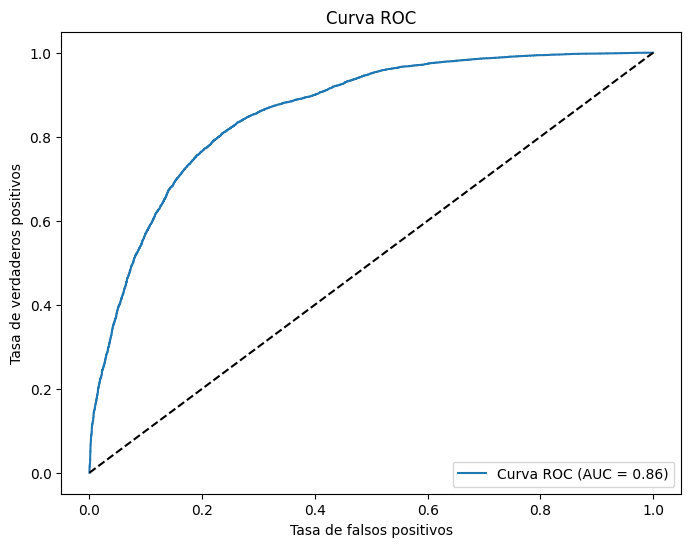

ROC-AUC: 0.790


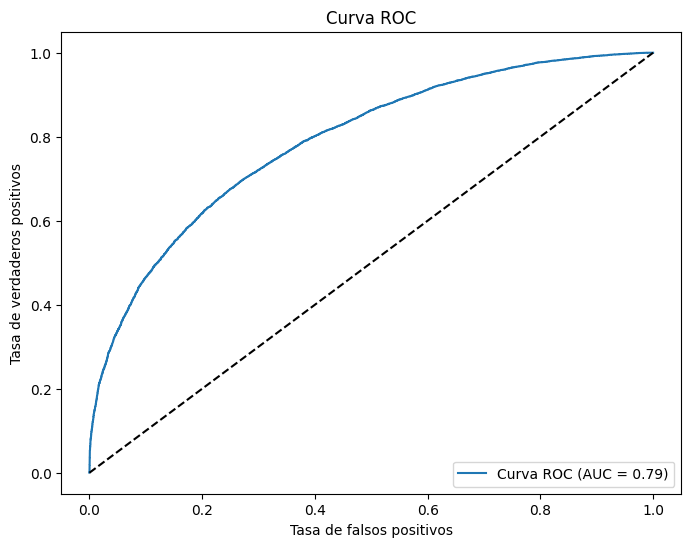

In [13]:
curva_roc(y_gru_pred, y_test)
curva_roc(y_lstm_pred, y_test)

---
## 🔎 Diagnóstico: ¿qué reseñas mal clasifica el modelo?

Analizar los **errores** es tan importante como analizar los aciertos. Los patrones de error revelan:
- Reseñas con **ironía o sarcasmo** ("¡Qué película tan maravillosa!" dicho con sarcasmo)
- Reseñas **ambiguas** (sentimientos mixtos)
- **Negaciones complejas** ("no es del todo mala")

> Estos casos difíciles son los que motivan arquitecturas más sofisticadas como los Transformers con mecanismo de atención.

#### 5.2 Visualiza los errores

### 🔡 De números a palabras: el diccionario inverso

El dataset IMDB almacena cada reseña como una lista de enteros. Para *leer* una reseña, necesitamos el mapeo inverso: entero → palabra.

**Índices reservados:**
- `0` → padding (relleno)
- `1` → `<START>` (inicio de secuencia)
- `2` → `<UNK>` (palabra desconocida)

Por eso restamos 3 al índice: el índice real en el diccionario es `idx - 3`.

In [15]:
#y_gru_pred = gru_model.predict(x_test)
# Convierte las probabilidades a etiquetas binarias usando un umbral de 0.5
y_pred = (y_gru_pred > 0.5).astype("int32").flatten()

# Identificar los índices mal clasificados
misclassified_idx = np.where(y_pred != y_test)[0]
print("Número de ejemplos mal clasificados:", len(misclassified_idx))

if len(misclassified_idx) > 0:
    # Seleccionamos el primer ejemplo mal clasificado
    idx = misclassified_idx[1]
    print(f"\nEjemplo mal clasificado en el índice {idx}:")
    print("Etiqueta real:", y_test[idx])
    print("Predicción:", y_pred[idx])
    
    # Mostrar la secuencia (como números)
    #print("\nSecuencia (token IDs):")
    #print(x_test[idx])
 # Si deseas visualizar la reseña en texto, es necesario decodificar la secuencia.
    # Para ello, construimos el diccionario inverso:
    word_index = imdb.get_word_index()
    # El dataset de IMDb reserva índices 0, 1 y 2 para padding, inicio de secuencia y desconocidos.
    reverse_word_index = {value: key for key, value in word_index.items()}
    
    def decode_review(sequence):
        # Se resta 3 a cada índice para compensar los tokens reservados.
        return ' '.join([reverse_word_index.get(i - 3, '?') for i in sequence if i >= 3])
    
    review_text = decode_review(x_test[idx])
    print("\nReseña decodificada:")
    print(review_text)
else:
    print("No se encontraron ejemplos mal clasificados.")

Número de ejemplos mal clasificados: 5881

Ejemplo mal clasificado en el índice 2:
Etiqueta real: 1
Predicción: 0

Reseña decodificada:
at a time when motion picture animation of all sorts was in its br br the political of the russian revolution caused to move to paris where one of his first productions was a dark political satire known as or the who wanted a king a strain of black comedy can be found in almost all of films but here it is very dark indeed aimed more at grown ups who can appreciate the satirical aspects than children who would most likely find the climax i'm middle aged and found it pretty myself and indeed of the film intended for english speaking viewers of the 1920s were given title cards filled with and in order to help the sharp of the finale br br our tale is set in a swamp the where the citizens are unhappy with their government and have called a special session to see what they can do to improve matters they decide to for a king the crowds are animated in this o